In [10]:
import uproot
import pandas as pd
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# Read NuSyst Tree ROOT file

In [11]:
with uproot.open("NuSystTree.root") as f:

    df_event = f["events"].arrays(library="pd")
    df_meta = f["tweak_metadata"].arrays(library="pd")

# Let's first look at the metadata tree

In [12]:
df_meta

,fUniqueID,fBits,fString,ntweaks,tweakvalues
0,0,50331648,DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA,3,[-1.0 0.0 1.0]
1,0,50331648,DUNEDAS2026ExampleReweighter_NuSystTutorial_DialB,3,[-1.0 0.0 1.0]


Metadata contains the dial and and its list of variations used when running `DumpConfiguredTweaksNuSyst`.
- Each row is for each dial
- "fString": "Full" name of the dial
  - <tool_type>_<instance_name>_<dial name>
- "ntweaks": Number of variations
- "Tweakvalues": Array of the variation

# Now let's look at the event tree

In [15]:
df_event.head(5)

,Mode,Mode_str,xsec,Emiss,Emiss_preFSI,Emiss_GENIE,pmiss,pmiss_preFSI,q0,Q2,...,fsprotons_KE,deltaPT,deltaalphaT,IsSignal_ICARUS_1muNp0pi,ntweaks_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA,tweak_responses_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA,paramCVWeight_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA,ntweaks_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialB,tweak_responses_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialB,paramCVWeight_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialB
0,-26,nu:-14;tgt:1000120240;N:2112;q:2(v);proc:Weak[...,2.399475e-37,0.133229,0.025236,0.025226,0.396137,0.164486,3.935479,0.263472,...,"[0.11656414809233606, 0.010571932195973632]",0.076045,87.248111,False,3,[1.0 1.0 1.0],1.0,3,[1.0 1.0 1.0],1.0
1,26,nu:14;tgt:1000140280;N:2212;q:1(v);proc:Weak[C...,2.148285e-36,0.003403,9.778102,0.018104,0.079464,12.476298,39.101997,17.985181,...,"[4.996315611471357, 0.1641275327714914, 0.0899...",2.172010,174.559169,False,3,[1.0 1.0 1.0],1.0,3,[1.0 1.0 1.0],1.0
2,-26,nu:-14;tgt:1000080160;N:2112;q:2(v);proc:Weak[...,3.173830e-37,0.147902,0.022806,0.022792,0.327815,0.179257,15.153722,9.848099,...,[0.05113549687884711],2.598964,176.873867,False,3,[1.0 1.0 1.0],1.0,3,[1.0 1.0 1.0],1.0
3,11,"nu:14;tgt:1000080160;N:2212;proc:Weak[CC],RES;...",5.401760e-38,0.007386,0.007386,0.013701,0.053959,0.053959,0.398221,0.124589,...,[0.16591634499029506],0.111213,91.763504,False,3,[1.0 1.0 1.0],1.0,3,[1.0 1.0 1.0],1.0
4,13,nu:14;tgt:1000260560;N:2112;q:1(v);proc:Weak[C...,3.673867e-37,-0.011714,0.013286,0.013280,0.251036,0.251036,1.710928,0.590215,...,"[0.011198496250344858, 0.010135123922363931, 0...",0.550483,170.817328,False,3,[1.0 1.0 1.0],1.0,3,[1.0 1.0 1.0],1.0


Event tree converts GENIE Event info into a simple flat tree.
Each row corresponds to a single GENIE interaction.
It contains various kinematic variables that desecribes the interaction.

For instance, we have neutrino energy in "Enu_true":

<Axes: >

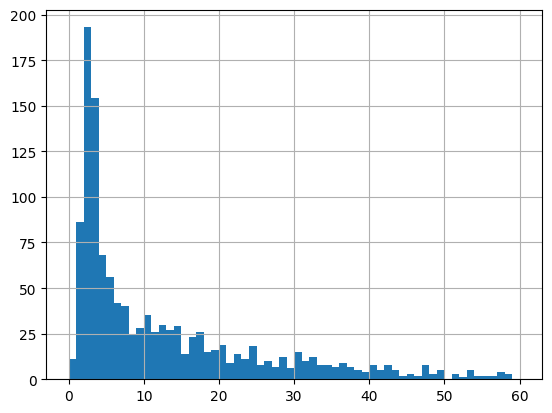

In [19]:
df_event["Enu_true"].hist(bins=np.linspace(0, 60, 60+1))

Above should be the same as what you see from the morning session!

Now, let's focus on the last few columns, which contains the reweight information

In [25]:
DialColumnName_prefix = "DUNEDAS2026ExampleReweighter_NuSystTutorial"
DialNames = ["DialA", "DialB"]

DialColNames = [
    f"ntweaks_{DialColumnName_prefix}_DialA",
    f"tweak_responses_{DialColumnName_prefix}_DialA",
    f"paramCVWeight_{DialColumnName_prefix}_DialA",
]

df_event[DialColNames].head(5)

,ntweaks_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA,tweak_responses_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA,paramCVWeight_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA
0,3,[1.0 1.0 1.0],1.0
1,3,[1.0 1.0 1.0],1.0
2,3,[1.0 1.0 1.0],1.0
3,3,[1.0 1.0 1.0],1.0
4,3,[1.0 1.0 1.0],1.0


- "ntweaks_(prefix)_(DialName)"
    - Number of variations for the Dial
    - Same as in the metadata
- "tweak_responses_(prefix)_(DialName)"
    - An array of the reweights for each variation
    - Reweight in this Tree is divided by the reweight of the "central_value"
    - The order of the elements are the same as "tweakvalues" from the metadata
- "paramCVWeight_(prefix)_(DialName)"
    - Reweight for the central_value
    - If the reweight from cental_value is not 1.0, this means we want to apply a "CV" correction using this dial, and the reweights are on top of that correction
    - For this tutorial, let's make RW(central_value) to be 1.0

As you can see, the reweights from the current module is all 1.0, so we stay at the CV.

Now let's modify "DUNEDAS2026ExampleReweighter" module!